# 1. Introduction. Write your answers in the Intro section of your notebook.

### 1

1. рекомендации в соц сетях ( оценивается очень много признаков( про целовека, его устройстро, модель телефона, геолокацию и тд), собирается досье на человека по его интересам и тд
и главное, что делает ml это пытается своими предсказаниями как можно удержать пользователя в приложении( по рекомендациям)
если бы мы использовали ручной перебор интересов, но видео с мотоциклами постепенно бы надоели пользователю )
2. решение при выдаче кредита человеку ( анализирует тысячи признаков про статус человека и его склонность к импульсивности, собирая данные с его телефона и скорости оформления других документов)
3. текст от нейронки ( если бы человек составил шаблоны ( как например во многих техподдержках) это практически бессмысленно, тк невозможно предсказать вопрос пользователя)
4. биометрия в метро( мне кажется тут невозможно прописать общие правила, тк форма лица, национальность у всех разные, также возможны другие факторы, такие как одежда, наушники и тд)
5. мошенничество онлайн( таких случаев за последнее время стало сотни тысяч за сутки и преимущество ml в том, что модель с каждой секундой обучается уже на новых данных ( база пополняется ежесекундно), даже команда людей в сутки не способна анализировать такой объем информации и успевать делать выводы + операции проводились бы в разы дольше)



### 2

1. regression
2. binary classification
3. binary classification
4. multilabel classification
5. clustering
6. binary classification
7. not ml
8. clustering
9. clustering
10. binary classification
11. rank ( multiclass classification)
12. binary classification
13. Sequence Generation / Language Modeling
14. binary classification
15. binary classification

### 3. 
multiclass - может быть только один вариант из группы ( порода собаки)
   multilabel - может быть несколько вариантов из группы ( жанры для фильма ( драма/комендия))


### 4.
теоритически можно, но скорее всего упадет точность предсказаний и будут слишком грубые округления, но если нам пребуется, например фильтр по "дорого", "дешево", то можно

# 2. Introduction to Data Analysis

# Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [ ]:
df = pd.read_json('../data/train.json')
df

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,6824800,-73.9396,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.0,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,6813268,-73.9578,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.0,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,6927093,-73.9554,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.0,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,6892816,-74.0017,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


In [ ]:
for col in df.columns:
    print(col)

bathrooms
bedrooms
building_id
created
description
display_address
features
latitude
listing_id
longitude
manager_id
photos
price
street_address
interest_level


### 4. target = price

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


In [ ]:
df.isna().any()

bathrooms          False
bedrooms           False
building_id        False
created            False
description        False
display_address    False
features           False
latitude           False
listing_id         False
longitude          False
manager_id         False
photos             False
price              False
street_address     False
interest_level     False
dtype: bool

In [ ]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


no

In [ ]:
df.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


In [ ]:
df_res = df[['bathrooms', 'bedrooms', 'interest_level', 'price']]
df_res

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795
...,...,...,...,...
124000,1.0,3,low,2800
124002,1.0,2,medium,2395
124004,1.0,1,medium,1850
124008,1.0,2,medium,4195


# 3. Statistical Data Analysis

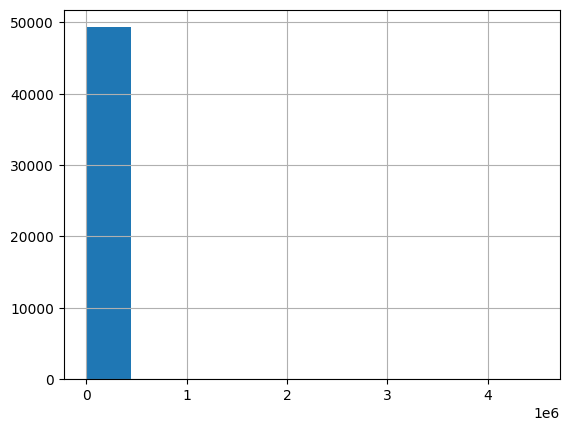

In [ ]:
df_res['price'].hist(bins=10)
plt.show()

понятно, что все очень плохо, есть большие выбросы

In [ ]:
df_res['price'].describe()

count    4.935200e+04
mean     3.830174e+03
std      2.206687e+04
min      4.300000e+01
25%      2.500000e+03
50%      3.150000e+03
75%      4.100000e+03
max      4.490000e+06
Name: price, dtype: float64

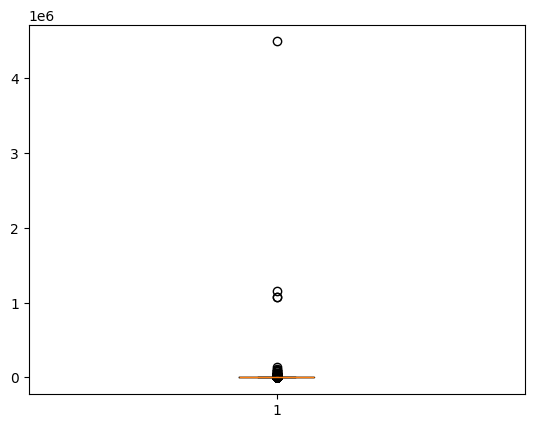

In [ ]:
plt.boxplot(df_res['price'])
plt.show()

есть выбросы

In [ ]:
df_res.sort_values(by='price')

,bathrooms,bedrooms,interest_level,price
53144,1.0,0,low,43
87511,1.0,0,low,45
117339,1.0,1,low,401
113599,1.0,0,medium,695
113552,1.0,0,medium,695
...,...,...,...,...
123877,0.0,0,low,135000
55437,1.0,1,low,1070000
57803,1.0,1,low,1070000
12168,1.0,2,low,1150000


In [ ]:
lower = df_res['price'].quantile(0.01)
upper = df_res['price'].quantile(0.99)
df_clean = df_res[(df_res['price'] >= lower) & (df_res['price'] <= upper)]
df_clean

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795
...,...,...,...,...
124000,1.0,3,low,2800
124002,1.0,2,medium,2395
124004,1.0,1,medium,1850
124008,1.0,2,medium,4195


<Axes: >

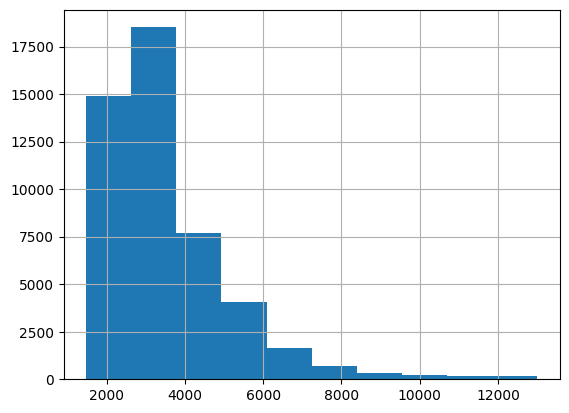

In [ ]:
df_clean['price'].hist()


уже лучше, хвост справа

In [ ]:
df_clean['price'].describe()

count    48379.000000
mean      3538.636888
std       1597.663167
min       1475.000000
25%       2500.000000
50%       3150.000000
75%       4065.000000
max      13000.000000
Name: price, dtype: float64

# 4. Characteristics Analysis

In [ ]:
df_clean['interest_level'].dtype

<StringDtype(storage='python', na_value=nan)>

In [ ]:
df_clean['interest_level'].unique()

<StringArray>
['medium', 'low', 'high']
Length: 3, dtype: str

In [ ]:
df_clean['interest_level'].value_counts()


interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

In [ ]:
mapping = {
    'low': 0, 'medium': 1, 'high': 2
}
df_clean['interest_level'] = df_clean['interest_level'].map(mapping)
df_clean

,bathrooms,bedrooms,interest_level,price
4,1.0,1,1,2400
6,1.0,2,0,3800
9,1.0,2,1,3495
10,1.5,3,1,3000
15,1.0,0,0,2795
...,...,...,...,...
124000,1.0,3,0,2800
124002,1.0,2,1,2395
124004,1.0,1,1,1850
124008,1.0,2,1,4195


<Axes: >

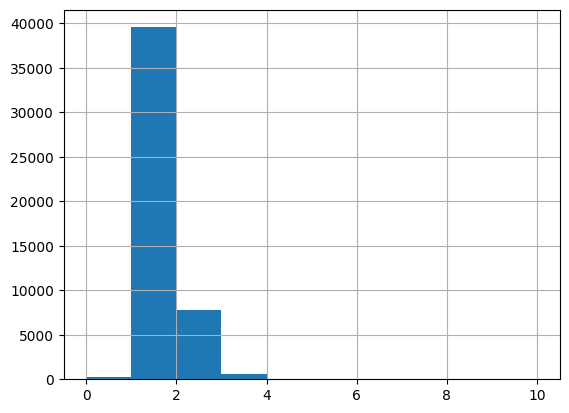

In [ ]:
df_clean['bathrooms'].hist()

In [ ]:
df_clean[df_clean['bathrooms'] == 10].shape[0]

1

<Axes: >

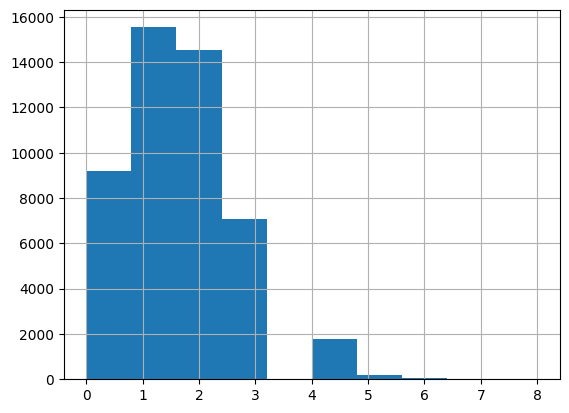

In [ ]:
df_clean['bedrooms'].hist()

и там, и там есть выбросы, это мы можем видеть по осям( числа до 8 и 10, а также в вызванной мною функции)

# 5. Complex analysis

In [ ]:
corr_matrix = df_clean.corr()

Text(0.5, 1.0, 'Correlation matrix for features')

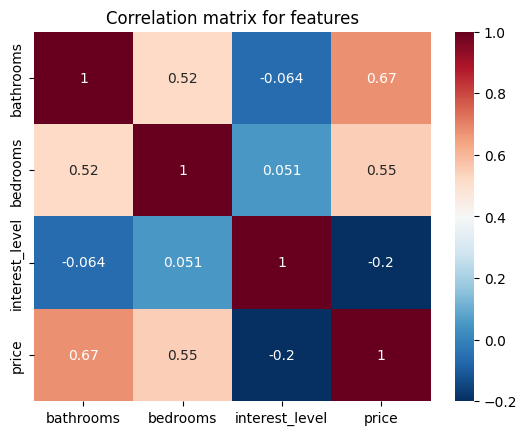

In [ ]:
sbn.heatmap(corr_matrix, cmap='RdBu_r', annot=True)
plt.title('Correlation matrix for features')

Матрица корреляции показывает, что связь между признаками (bathrooms, bedrooms, interest_level) и ценой очень слабая (коэффициенты менее 0.1). Это говорит о том, что цена квартиры плохо объясняется только этими признаками и требует дополнительных факторов, таких как площадь, описание, местоположение.

Text(0.5, 1.0, 'scatterplot Price vs Bathrooms on df_clean')

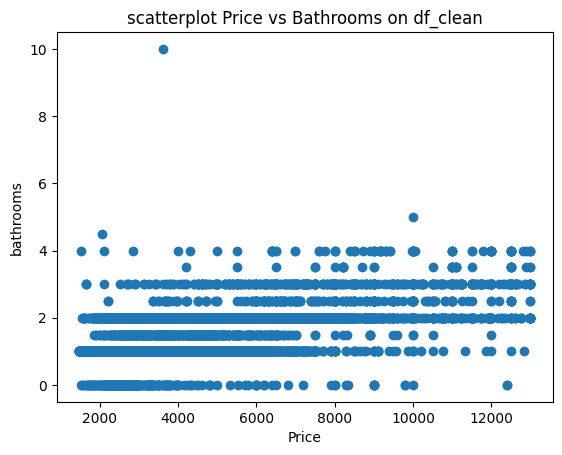

In [ ]:
features = df_clean.drop(columns='price')
target = df_clean['price']
plt.scatter(x=target, y= df_clean['bathrooms'])
plt.xlabel('Price')
plt.ylabel('bathrooms')
plt.title('scatterplot Price vs Bathrooms on df_clean')

❌ признак не меняется с ростом цены

Text(0.5, 1.0, 'scatterplot Price vs Bedrooms on df_clean')

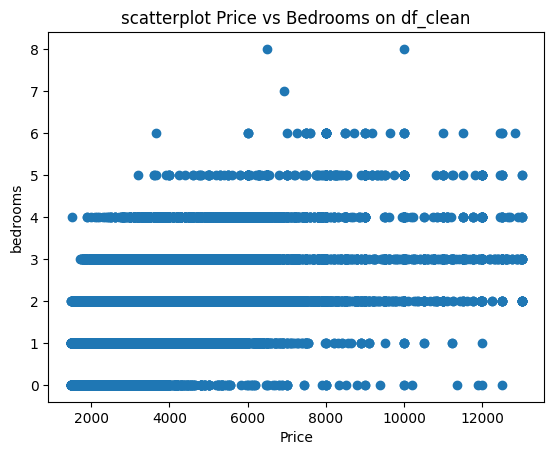

In [ ]:
plt.scatter(x = target, y = df_clean['bedrooms'])
plt.xlabel('Price')
plt.ylabel('bedrooms')
plt.title('scatterplot Price vs Bedrooms on df_clean')

❌ признак не меняется с ростом цены

Text(0.5, 1.0, 'scatterplot Price vs interest level on df_clean')

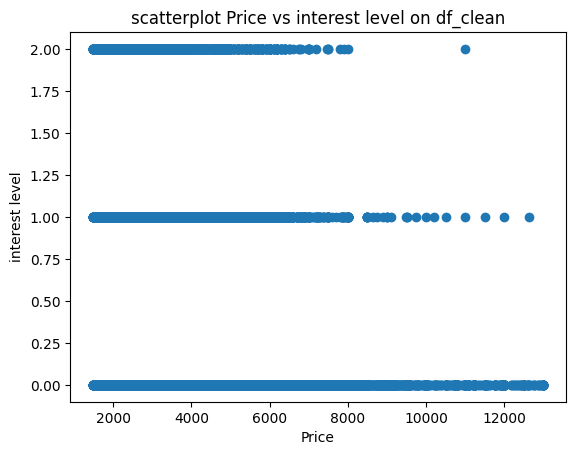

In [ ]:
plt.scatter(x = target, y = df_clean['interest_level'])
plt.xlabel('Price')
plt.ylabel('interest level')
plt.title('scatterplot Price vs interest level on df_clean')

❌ признак не меняется с ростом цены

# 4. Creating Features

In [ ]:
df_clean['bathrooms_squared'] = df_clean['bathrooms'] ** 2
df_clean['bedrooms_squared'] = df_clean['bedrooms'] ** 2
df_clean['interest_level_squared'] = df_clean['interest_level'] ** 2
df_clean

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
4,1.0,1,1,2400,1.00,1,1
6,1.0,2,0,3800,1.00,4,0
9,1.0,2,1,3495,1.00,4,1
10,1.5,3,1,3000,2.25,9,1
15,1.0,0,0,2795,1.00,0,0
...,...,...,...,...,...,...,...
124000,1.0,3,0,2800,1.00,9,0
124002,1.0,2,1,2395,1.00,4,1
124004,1.0,1,1,1850,1.00,1,1
124008,1.0,2,1,4195,1.00,4,1


In [ ]:
corr_matrix_squared = df_clean[['bathrooms_squared', 'bedrooms_squared', 'interest_level_squared', 'price']].corr()
corr_matrix_squared

,bathrooms_squared,bedrooms_squared,interest_level_squared,price
bathrooms_squared,1.000000,0.522227,-0.062240,0.648486
bedrooms_squared,0.522227,1.000000,0.035718,0.543406
interest_level_squared,-0.062240,0.035718,1.000000,-0.182672
price,0.648486,0.543406,-0.182672,1.000000


(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0.5, 0, 'bathrooms_squared'),
  Text(1.5, 0, 'bedrooms_squared'),
  Text(2.5, 0, 'interest_level_squared'),
  Text(3.5, 0, 'price')])

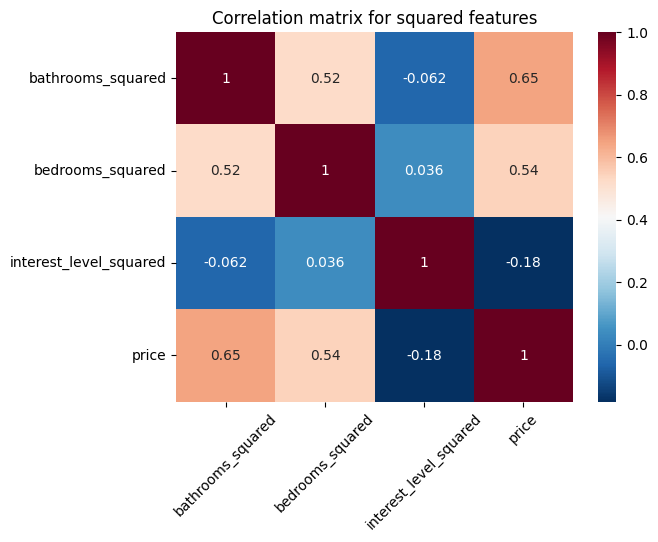

In [ ]:
sbn.heatmap(corr_matrix_squared, cmap='RdBu_r', annot=True)
plt.title('Correlation matrix for squared features')
plt.xticks(rotation = 45)

Корреляция квадратов признаков с ценой значительно выше, чем у исходных признаков. bathrooms_squared показывает умеренную положительную связь (0.65), bedrooms_squared — также умеренную (0.54). Это подтверждает нелинейный характер зависимости: увеличение количества комнат/ванн сильнее влияет на цену при более высоких значениях.

In [ ]:
X_train = df_clean[['bathrooms', 'bedrooms']]
y_train = df_clean['price']

df_test = pd.read_json('../data/test.json')
X_test = df_test[['bathrooms', 'bedrooms']]
y_test = df_test['price']
df_test.isna().any()


bathrooms          False
bedrooms           False
building_id        False
created            False
description        False
display_address    False
features           False
latitude           False
listing_id         False
longitude          False
manager_id         False
photos             False
price              False
street_address     False
dtype: bool

In [ ]:
poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(X_train.shape)
print(X_train_poly.shape)
print(X_test.shape)
print(X_test_poly.shape)

(48379, 2)
(48379, 66)
(74659, 2)
(74659, 66)


# 5. Now you need to train 3 models: linear regression, decision tree and naive model. We will use them as black boxes without deep understanding.

In [ ]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr_train = lr.predict(X_train)
y_pred_lr_test = lr.predict(X_test)

mae_train_lr = mean_absolute_error(y_train, y_pred_lr_train)
mae_test_lr = mean_absolute_error(y_test, y_pred_lr_test)

rmse_train_lr = root_mean_squared_error(y_train, y_pred_lr_train)
rmse_test_lr = root_mean_squared_error(y_test, y_pred_lr_test)

new_row_mae = pd.DataFrame({
    'model': ['linear_regression'],
    'train': [mae_train_lr],
    'test': [mae_test_lr]

})
new_row_rmse = pd.DataFrame({
    'model': ['linear_regression'],
    'train': [rmse_train_lr],
    'test': [rmse_test_lr]

})
result_MAE = pd.concat([result_MAE, new_row_mae], ignore_index=True)
result_RMSE = pd.concat([result_RMSE, new_row_rmse], ignore_index=True)

df_clean['price_pred_lr']

In [ ]:
dt = DecisionTreeRegressor(random_state=21)
dt.fit(X_train, y_train)
y_pred_dt_train = dt.predict(X_train)
y_pred_dt_test = dt.predict(X_test)

mae_train_dt = mean_absolute_error(y_train, y_pred_dt_train)
mae_test_dt = mean_absolute_error(y_test, y_pred_dt_test)
 
rmse_train_dt = root_mean_squared_error(y_train, y_pred_dt_train)
rmse_test_dt = root_mean_squared_error(y_test, y_pred_dt_test)

new_row_mae = pd.DataFrame({
    'model': ['decision_tree'],
    'train': [mae_train_dt],
    'test': [mae_test_dt]

})
new_row_rmse = pd.DataFrame({
    'model': ['decision_tree'],
    'train': [rmse_train_dt],
    'test': [rmse_test_dt]

})

result_MAE = pd.concat([result_MAE, new_row_mae], ignore_index=True)
result_RMSE = pd.concat([result_RMSE, new_row_rmse], ignore_index=True)

In [ ]:
mean_price = y_train.mean()
median_price = y_train.median()

y_pred_mean_train = [mean_price] * len(y_train)  
y_pred_mean_test = [mean_price] * len(y_test)

y_pred_median_train = [median_price] * len(y_train)
y_pred_median_test = [median_price] * len(y_test)

mae_mean_train = mean_absolute_error(y_train, y_pred_mean_train)
mae_mean_test = mean_absolute_error(y_test, y_pred_mean_test)
rmse_mean_train = root_mean_squared_error(y_train, y_pred_mean_train)
rmse_mean_test = root_mean_squared_error(y_test, y_pred_mean_test)

mae_median_train = mean_absolute_error(y_train, y_pred_median_train)
mae_median_test = mean_absolute_error(y_test, y_pred_median_test)
rmse_median_train = root_mean_squared_error(y_train, y_pred_median_train)
rmse_median_test = root_mean_squared_error(y_test, y_pred_median_test)

new_row_mean_mae = pd.DataFrame({
    'model': ['naive_mean'],
    'train': [mae_mean_train],
    'test': [mae_mean_test]
})

new_row_median_mae = pd.DataFrame({
    'model': ['naive_median'],
    'train': [mae_median_train],
    'test': [mae_median_test]
})

result_MAE = pd.concat([result_MAE, new_row_mean_mae, new_row_median_mae], ignore_index=True)

new_row_mean_rmse = pd.DataFrame({
    'model': ['naive_mean'],
    'train': [rmse_mean_train],
    'test': [rmse_mean_test]
})

new_row_median_rmse = pd.DataFrame({
    'model': ['naive_median'],
    'train': [rmse_median_train],
    'test': [rmse_median_test]
})

result_RMSE= pd.concat([result_RMSE, new_row_mean_rmse, new_row_median_rmse], ignore_index=True)

In [ ]:
result_MAE

,model,train,test
0,linear_regression,784.563837,986.046717
1,decision_tree,756.044735,953.592155
2,naive_mean,1139.192515,1374.695973
3,naive_median,1086.210505,1322.640673


In [ ]:
result_RMSE

,model,train,test
0,linear_regression,1123.877748,9625.054818
1,decision_tree,1077.483596,9589.260857
2,naive_mean,1597.646655,9715.305011
3,naive_median,1644.236439,9731.481148


Лучшей моделью является Decision Tree, так как она показывает наименьшие значения MAE и RMSE на тестовой выборке (953.6 и 9589 соответственно). Это говорит о том, что дерево решений лучше обобщает данные, чем линейная регрессия или наивные модели. При этом разница между метриками на train и test невелика, что свидетельствует об отсутствии сильного переобучения.